In [1]:
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader, random_split, Dataset, Subset
from torchvision import datasets, transforms
from tqdm import tqdm
from torch.optim import Optimizer
from torchsummary import summary
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold

from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize

In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ml_intensive_yandex_academy_spring_2026_path = kagglehub.competition_download('ml-intensive-yandex-academy-spring-2026')

print('Data source import complete.')


Data source import complete.


In [4]:
main_dir = '/root/.cache/kagglehub/competitions/ml-intensive-yandex-academy-spring-2026'

In [5]:
train_dir = main_dir + '/dataset/train_images'
test_dir = main_dir + '/dataset/test_images'
solution = main_dir + '/dataset/train_solution.csv'

In [6]:
train_df = pd.read_csv(solution, header=None, names=['id', 'val'])
train_df = train_df.set_index('id')

In [7]:
train_df

,val
id,
0,0
1,1
2,1
3,0
4,0
...,...
49995,0
49996,0
49997,0


In [8]:
train_df['tmp_ind'] = train_df.index

In [9]:
train_df['path'] = train_df['tmp_ind'].apply(lambda x: os.path.join(train_dir, str(x) + '.jpg'))

In [10]:
train_df = train_df.drop('tmp_ind', axis=1)
train_df

,val,path
id,,
0,0,/root/.cache/kagglehub/competitions/ml-intensi...
1,1,/root/.cache/kagglehub/competitions/ml-intensi...
2,1,/root/.cache/kagglehub/competitions/ml-intensi...
3,0,/root/.cache/kagglehub/competitions/ml-intensi...
4,0,/root/.cache/kagglehub/competitions/ml-intensi...
...,...,...
49995,0,/root/.cache/kagglehub/competitions/ml-intensi...
49996,0,/root/.cache/kagglehub/competitions/ml-intensi...
49997,0,/root/.cache/kagglehub/competitions/ml-intensi...


In [11]:
class TrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        val = torch.tensor(row['val'])

        if self.transform:
            img = self.transform(img)

        return img, val

In [12]:
class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        path = os.path.join(self.img_dir, img_name)

        img = Image.open(path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, img_name

In [13]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
device

device(type='cuda')

In [16]:
import random

In [17]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [18]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['val']
)

train_dataset = TrainDataset(df_train, train_transform)
val_dataset = TrainDataset(df_val, test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [19]:
test_dataset = TestDataset(test_dir, test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [20]:
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [21]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=1):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.spatial_dropout = nn.Dropout2d(p=0.3)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

model = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=1).to(device)

In [22]:
def plot_training_stats(train_losses, train_metrics, test_losses, test_metrics, metric_name='F1-score', title='Test'):
    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax1.plot(test_losses, label='Test Loss', color='red', linewidth=2)
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(train_metrics, label=f'Train {metric_name}', color='blue', linewidth=2)
    ax2.set_title(f'{title} - {metric_name}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel(metric_name)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(test_metrics, label=f'Test {metric_name}', color='red', linewidth=2)
    ax2.set_title(f'{title} - {metric_name}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel(metric_name)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.show()

In [23]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = FocalLoss(alpha=0.8, gamma=2.0)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [25]:
import torch.nn as nn
from torch.optim import Optimizer

def train_model(epochs, model_save_path='/content/drive/MyDrive/best_resnet.pth'):
    history_loss_train = []
    history_f1_train = []
    history_loss_val = []
    history_f1_val = []

    best_val_f1 = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss_train = 0.0
        all_targets_train = []
        all_predictions_train = []

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss_train += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) >= 0.5).float()
            all_targets_train.extend(targets.cpu().numpy())
            all_predictions_train.extend(predicted.cpu().numpy())

        epoch_loss_train = running_loss_train / len(train_loader.dataset)
        epoch_f1_train = f1_score(all_targets_train, all_predictions_train)

        history_loss_train.append(epoch_loss_train)
        history_f1_train.append(epoch_f1_train)

        model.eval()
        running_loss_val = 0.0
        all_targets_val = []
        all_predictions_val = []

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.float().unsqueeze(1).to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                running_loss_val += loss.item() * inputs.size(0)
                predicted = (torch.sigmoid(outputs) >= 0.5).float()
                all_targets_val.extend(targets.cpu().numpy())
                all_predictions_val.extend(predicted.cpu().numpy())

        epoch_loss_val = running_loss_val / len(val_loader.dataset)
        epoch_f1_val = f1_score(all_targets_val, all_predictions_val)

        history_loss_val.append(epoch_loss_val)
        history_f1_val.append(epoch_f1_val)

        plot_training_stats(
            history_loss_train, history_f1_train,
            history_loss_val, history_f1_val,
            metric_name='F1-score',
            title="ResNet-34"
        )

        if epoch_f1_val > best_val_f1:
            best_val_f1 = epoch_f1_val
            torch.save(model.state_dict(), model_save_path)
            print(f"\n\n\nлучший F1: {best_val_f1:.4f}")

        print(f'Epoch [{epoch}/{epochs}] | Train Loss: {epoch_loss_train:.4f} | Train F1: {epoch_f1_train:.4f} | Val Loss: {epoch_loss_val:.4f} | Val F1: {epoch_f1_val:.4f}')


In [26]:
from sklearn.metrics import f1_score

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


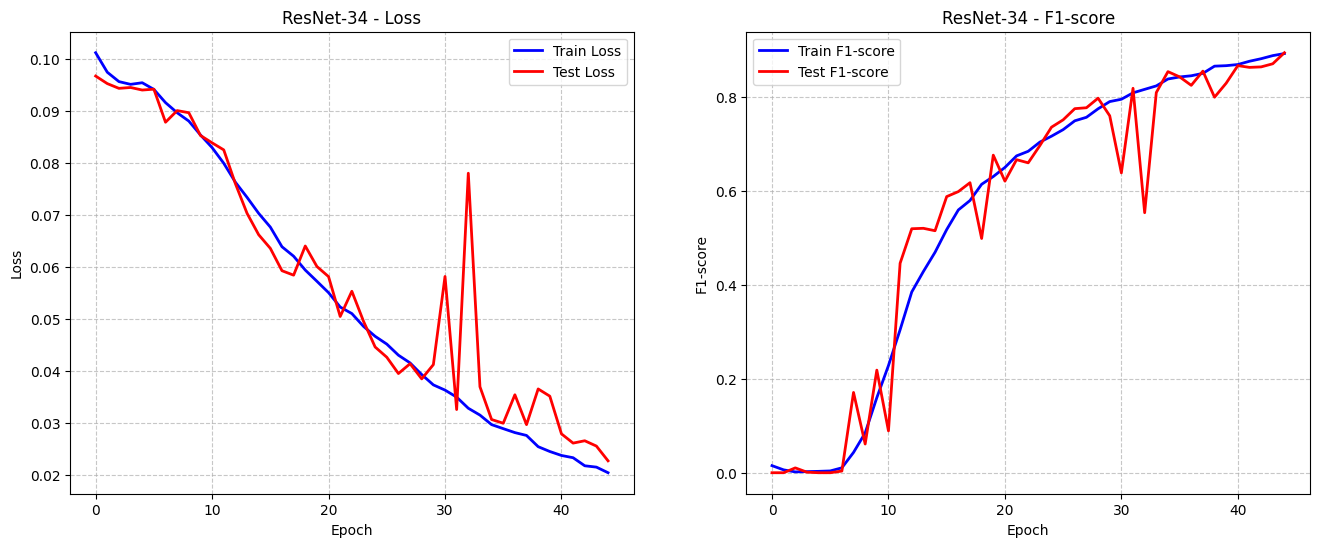




лучший F1: 0.8935
Epoch [45/50] | Train Loss: 0.0204 | Train F1: 0.8917 | Val Loss: 0.0227 | Val F1: 0.8935


In [ ]:
train_model(epochs=50)

In [ ]:
def generate_submission(model, test_loader, device, filename='/content/drive/MyDrive/submission.csv'):
    model.eval()
    predictions = []

    with torch.no_grad():
        for inputs in test_loader:
            if isinstance(inputs, (list, tuple)):
                inputs = inputs[0]

            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).int().cpu().numpy()

            predictions.extend(preds.flatten())

    submission_df = pd.DataFrame({
        'Id': range(len(predictions)),
        'target_feature': predictions
    })

    submission_df.to_csv(filename, index=False)
    print(f"{filename}. Кол-во строк: {len(submission_df)}")

generate_submission(model, test_loader, device)